## Ornstein-Uhlenbeck (OU)

In [106]:
#  importing packages
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np

# 1. fetching data 
GLD = yf.download('GLD', start = "2018-01-01", end = "2024-01-01")
GDX = yf.download('GDX', start = "2018-01-01", end = "2024-01-01")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [107]:
# Selecting only the closing prices and removing missing values
D_close = GLD['Close'].dropna()
X_close = GDX['Close'].dropna()
# checking to make sure trading days are aligned
assert sum(~(D_close.index == X_close.index)) == 0, "Ensure that every row correspond to the same trading day"

# 2. Calculating the Hedge Regression 
# Suppose GDX and GLD are related
# calculating relation using the Odinary Least Square (OLS) regression and asking "How much GDX is needed to hedge one unit of GLD?"
# Let GDX be the explanatory variable and GLD the dependent variable

# adding a constant to the regression to account for the intercept.
X_con = sm.add_constant(np.log(X_close))
ols_model = sm.OLS(np.log(D_close), X_con).fit()
hedge_ratio = ols_model.params.iloc[1]
print(f"Hedge Ratio: {hedge_ratio: .4f}")

Hedge Ratio:  0.6562


In [108]:
# 3. Calculating Spread
# Spread = GLD - (Hedge Ratio * GDX)
Spread = np.log(D_close).values - hedge_ratio * np.log(X_close)
# 4. Testing for Cointegration
# Null hypothesis is that the spread is non-stationary (behaves like a random walk)
# Alternate Hypothesis is that the spread is stationary (reverts to a long-term mean)
# Testing using Augmented Dickey-Fuller (ADF) Test with significance level 0.05

# testing 
adf_result = adfuller(Spread)
p_value = adf_result[1]
print(f"ADF Test p-value: {adf_result[1]: .6f}")
# If the p-value is < 0.05, we reject the null and prove the spread is mean-reverting.
if p_value < 0.05:
    print("Result: The spread is mathematically STATIONARY (Conintegrated). We can trade this")
else:
    print("Result: The spread is a random walk. Do NOT trade this pair.")

ADF Test p-value:  0.336011
Result: The spread is a random walk. Do NOT trade this pair.


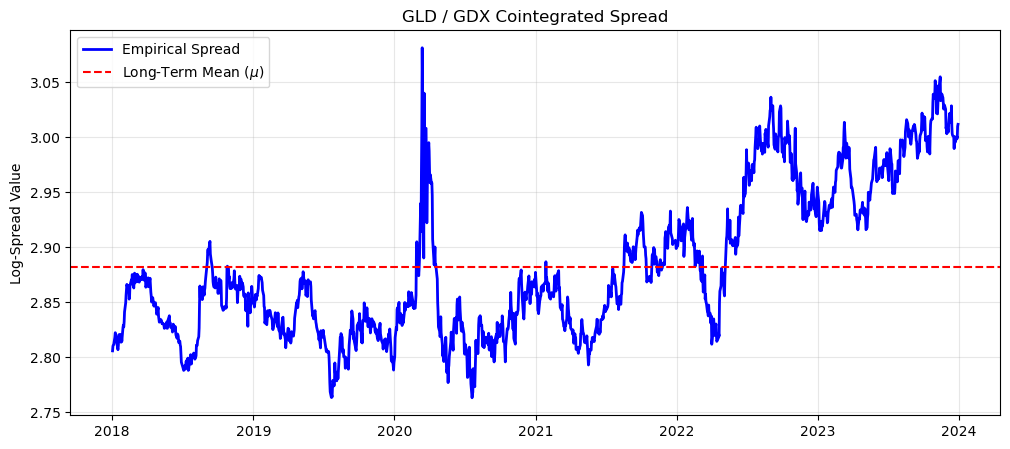

In [109]:
# 5. Visualization of the Spread 
plt.figure(figsize=(12,5))
plt.plot(Spread.index, Spread.values, label = 'Empirical Spread', color = 'blue', lw = 2)
plt.axhline(Spread.values.mean(), color = 'red', linestyle = '--', label = 'Long-Term Mean ($\mu$)')
plt.title("GLD / GDX Cointegrated Spread")
plt.ylabel("Log-Spread Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("gldgdx_cointegrated_spread.png", dpi=300, bbox_inches='tight')
plt.show()

#### For pairs GOOG and GOOGL

In [110]:
# Fetching data
goog = yf.download('GOOG', start = "2018-01-01", end = "2024-01-01")
googl = yf.download('GOOGL', start = "2018-01-01", end = "2024-01-01")

# Selecting only the closing prices and removing missing values
goog_close = goog['Close'].dropna()
googl_close = googl['Close'].dropna()
# checking to make sure trading days are aligned
assert sum(~(goog_close.index == googl_close.index)) == 0, "Ensure that every row correspond to the same trading day!"

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [111]:
# 2. Calculating the Hedge Regression 
# Suppose GOOG and GOOGL are related
# calculating relation using the Odinary Least Square (OLS) regression and asking "How much GDX is needed to hedge one unit of GLD?"
# Let GOOGL be the explanatory variable and GOOG the dependent variable

# adding a constant to the regression to account for the intercept.
googl_con = sm.add_constant(np.log(googl_close))
ols_model_1 = sm.OLS(np.log(goog_close), googl_con).fit()
hedge_ratio_1 = ols_model_1.params.iloc[1]
print(f"Hedge Ratio: {hedge_ratio_1: .4f}")

Hedge Ratio:  1.0148


In [112]:
# 3. Calculating Spread
# Spread = GOOG - (Hedge Ratio * GOOGL)
Spread_1 = np.log(goog_close).values - hedge_ratio_1 * np.log(googl_close)
# 4. Testing for Cointegration
# Null hypothesis is that the spread is non-stationary (behaves like a random walk)
# Alternate Hypothesis is that the spread is stationary (reverts to a long-term mean)
# Testing using Augmented Dickey-Fuller (ADF) Test with significance level 0.05

# testing 
adf_result_1 = adfuller(Spread_1)
p_value_1 = adf_result_1[1]
print(f"ADF Test p-value: {adf_result_1[1]: .6f}")
# If the p-value is < 0.05, we reject the null and prove the spread is mean-reverting.
if p_value_1 < 0.05:
    print("Result: The spread is mathematically STATIONARY (Conintegrated). We can trade this")
else:
    print("Result: The spread is a random walk. Do NOT trade this pair.")

ADF Test p-value:  0.002314
Result: The spread is mathematically STATIONARY (Conintegrated). We can trade this


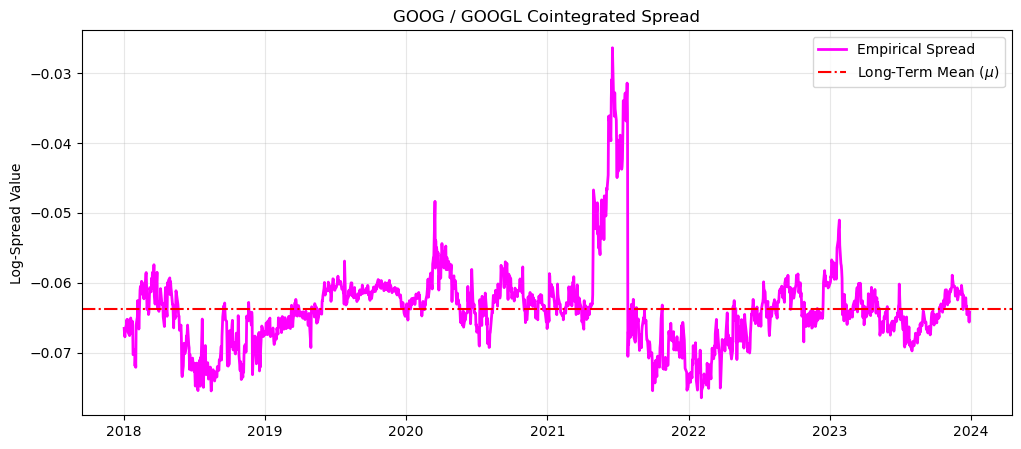

In [113]:
# 5. Visualization of the Spread 
plt.figure(figsize=(12,5))
plt.plot(Spread_1.index, Spread_1.values, label = 'Empirical Spread', color = 'magenta', lw = 2)
plt.axhline(Spread_1.values.mean(), color = 'red', linestyle = '-.', label = 'Long-Term Mean ($\mu$)')
plt.title("GOOG / GOOGL Cointegrated Spread")
plt.ylabel("Log-Spread Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("goog_googl_cointegrated_spread.png", dpi = 300, bbox_inches='tight') 
plt.show()

### Maximun Likelihood Estimation (MLE) and the Half-Life

In [114]:
# 1. Prepare the data for the OU Regression
# We want to regress the change in the spread against the lagged spread
spread_dt = Spread_1.diff().dropna()
spread_lag = Spread_1.shift(1).dropna()

# 2. Run the OLS Regression
# Equation: daily change in spread = a + b *  Spread_{t-1} + e
X = sm.add_constant(spread_lag)
ou_model = sm.OLS(spread_dt, X).fit()

# 3. Extract parameters 
# The slope 'b' is mathematically equivalent to -theta
speed = -ou_model.params.iloc[1]

# 4. Calculate the Half-Life
half_life = np.log(2) / speed

print(f"Speed of mean reversion:{speed: .6f}")
print(f"Half-Life of Spread:{half_life: .6f} days.")

Speed of mean reversion: 0.052775
Half-Life of Spread: 13.133906 days.


### Trading Algorithm

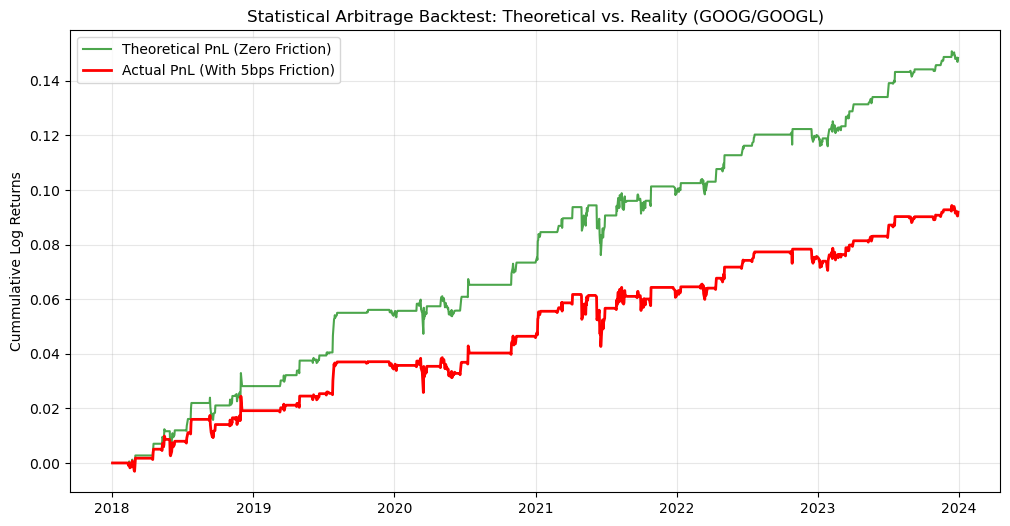

Total Number of Trades Executed:113
Theoretical Final PnL:0.1484
Actual Final PnL (After Friction):0.0919


In [115]:
import pandas as pd

# 1. Calculate the Rolling Z-Score
# Use a rolling window of twice that the half-life to dynamically track the mean 
wind = int(half_life * 2)
spread_mean = Spread_1.rolling(window=wind).mean()
spread_std = Spread_1.rolling(window=wind).std()
z_score = ((Spread_1 - spread_mean) / spread_std).squeeze()

# 2. Generate Trading Signals 
# 1 = Long the spread, -1 = Short the spread, 0 = Flat
# We use numpy.select for a fast conditional logic
conditions = [
    (z_score > 2.0),             # Spread is too high -> Short
    (z_score < -2.0),            # Spread is too low -> Long
    (abs(z_score) < 0.5)         # Spread reverted -> Exit (Flat)
]
choices = [-1, 1, 0]

# Initializing positions array with NaNs and then applying conditions 
positions = np.select(conditions, choices, default = np.nan)

# Forward fill the positions (if we enter a trade, we hold it until the exit condition is met)
# Then fill any remaining NaNs at the start with 0
positions = pd.Series(positions, index=Spread_1.index).ffill().fillna(0)

# 3. Calculating Returns 
# The daily PnL of holding the spread
spread_returns = Spread_1.diff()

# Theoretical PnL: Position from yesterday * today's return
# We shift positions by 1 to avoid look-ahead bias (you trade at close, earn tomorrow's return)
theoretical_returns = positions.shift(1) * spread_returns.values.flatten()
theoretical_pnl = theoretical_returns.cumsum().fillna(0)

# 4. Introducing Market Friction
# Every time our position changes, we cross the bid-ask spread and pay commissions
trades = positions.diff().abs().fillna(0)

# Assume 5 basis points (0.05%) of total friction per trade leg
friction_per_trade = 0.0005
friction_costs = (trades * friction_per_trade).cumsum()

# Actual PnL
actual_pnl = theoretical_pnl - friction_costs

# 5. Visualization
plt.figure(figsize=(12,6))
plt.plot(theoretical_pnl.index, theoretical_pnl, label='Theoretical PnL (Zero Friction)', color='green', alpha=0.7)
plt.plot(actual_pnl.index, actual_pnl, label='Actual PnL (With 5bps Friction)', color='red', linewidth=2)
plt.title("Statistical Arbitrage Backtest: Theoretical vs. Reality (GOOG/GOOGL)")
plt.ylabel("Cummulative Log Returns")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("statarb.png", dpi = 300, bbox_inches='tight')
plt.show()

# Print Final Stats
print(f"Total Number of Trades Executed:{trades.sum():.0f}")
print(f"Theoretical Final PnL:{theoretical_pnl.iloc[-1]:.4f}")
print(f"Actual Final PnL (After Friction):{actual_pnl.iloc[-1]:.4f}")